In [1]:
import os
import sys
import yaml
import torch
sys.path.append('../../')
import numpy as np
import pandas as pd
import networkx as nx
from utils import utils
from utils.operation import *
from datetime import datetime
import matplotlib.pyplot as plt
from types import SimpleNamespace
from utils.metrics import select_metric

from Data.data_collect.Merge_collect import Merge_PygDataset
from Data.data_collect.datatype.excel.excel_collect import Excel_PygDataset
from Data.data_collect.datatype.spectrum.spe_collect import Spectrum_PygDataset
from Data.data_collect.datatype.knowledge_map.k_p_collect import Knowledge_graph_PygDataset

from task_data.graph.graph_task_dataset import MolOFADataset
from task_data.graph.graph_construct import ConstructMolCls
from task_data.eval_data_construct import make_data,make_train_data,make_full_dm_list

from Models.LLM.LLM_Encoder import SentenceEncoder
from Models.models import PyGRGCNEdge,BinGraphModel,BinGraphAttModel


from Light.train import lightning_fit
from Light.data_module import DataModule
from Light.metric import flat_binary_func,EvalKit
from Light.template import ExpConfig,GraphPredLightning
from pytorch_lightning.loggers import WandbLogger

bin C:\Users\ljh\AppData\Roaming\Python\Python310\site-packages\bitsandbytes\libbitsandbytes_cuda116.dll


In [23]:
task_indicator = 4

# KG

In [2]:
# 加载知识图谱
Knowledge_graph_loader = Knowledge_graph_PygDataset()
FGD = Knowledge_graph_loader.data_loader('../../Datasets/Knowledge graph(chemistry)/knowledge_graph.gexf','graph')

In [10]:
# 加载振动信息
addition_information = Excel_PygDataset()
supplement_data = addition_information.data_loader('../../Datasets/Functional group (chemistry)/Functional_group_data_from_wiki_format.xlsx','text')
process_data = addition_information.preprocess()

In [11]:
# 图数据：FGD.data['1']['Data']
G = FGD.data['1']['Data'].copy()
# 给G添加复数节点：节点的名称为'Functional group{}';可能存在的振动节点；光谱范围节点
# 加入relation关系 ，has'range'
# {}为自然数列，从1开始，每个节点包含'raw_text'和'color'两个属性".
Append_node = []
Append_edge = []
for i in range(len(process_data)):
    # 检测该节点是否存在
    Subtype = ('#' + process_data.loc[i,'Subtype']).replace(' ','')
    core = ''

    dictionary_node = []
    dictionary_edge = []

    G.add_node(f'Range{i+1}',raw_text = process_data.iloc[i]['Range'],color = 'purple')
    dictionary_node.append(process_data.iloc[i]['Range'])
    G.add_node(f'S-Strength{i+1}',raw_text = process_data.iloc[i]['S-Strength'],color = 'yellow')
    dictionary_node.append(process_data.iloc[i]['S-Strength'])

    if process_data.iloc[i]['Functional group']!=None:
        core = ('#' + process_data.loc[i,'Functional group']).replace(' ','')
    else:
        core = Subtype
    if core not in G.nodes:
        G.add_node(core,raw_text = 'feature node. Functional group: <{}>.'.format(core),color = 'cyan')
    else:# 给节点core添加属性
        G.nodes[core]['raw_text'] = 'feature node. Functional group: <{}>.'.format(core)
        G.nodes[core]['color'] = 'cyan'
    if not G.has_edge(core,Subtype):
        G.add_edge(core,Subtype,relation='http://www.w3.org/1999/02/22-rdf-syntax-ns#type',id='2736')
            
    dictionary_node.append(core)

    if not G.has_edge(core,f'Range{i+1}'):
        G.add_edge(core,f'Range{i+1}',relation='feature edge.The absorption peak of this functional group cover the following range')
        dictionary_edge.append('FP-Ran')
    if not G.has_edge(f'Range{i+1}',f'S-Strength{i+1}'):
        G.add_edge(f'Range{i+1}',f'S-Strength{i+1}',relation='feature edge.The vibrational intensity of this absorption peak is as follows')
        dictionary_edge.append('Ran-Str')

    if process_data.iloc[i]['Absorb']!=None and process_data.iloc[i]['Absorb'] not in G.nodes:
        G.add_node(process_data.iloc[i]['Absorb'],raw_text = process_data.iloc[i]['Absorb'],color = 'yellow')
        dictionary_node.append(process_data.iloc[i]['Absorb'])
        if not G.has_edge(f'Range{i+1}',process_data.iloc[i]['Absorb']):
            G.add_edge(f'Range{i+1}',process_data.iloc[i]['Absorb'],relation='feature edge.The type of vibration of this absorption peak is as follows')
            dictionary_edge.append('Ran-Ab')
    elif process_data.iloc[i]['Absorb']!=None and process_data.iloc[i]['Absorb'] in G.nodes:
        dictionary_node.append(process_data.iloc[i]['Absorb'])
        if not G.has_edge(f'Range{i+1}',process_data.iloc[i]['Absorb']):
            G.add_edge(f'Range{i+1}',process_data.iloc[i]['Absorb'],relation='feature edge.The type of vibration of this absorption peak is as follows')
            dictionary_edge.append('Ran-Ab')
    
    Append_node.append(dictionary_node)
    Append_edge.append(dictionary_edge)

In [12]:
for i in range(len(process_data)):
    nx.relabel_nodes(G,{f'Range{i+1}':process_data.iloc[i]['Range']},copy=False)
FG_graph = G

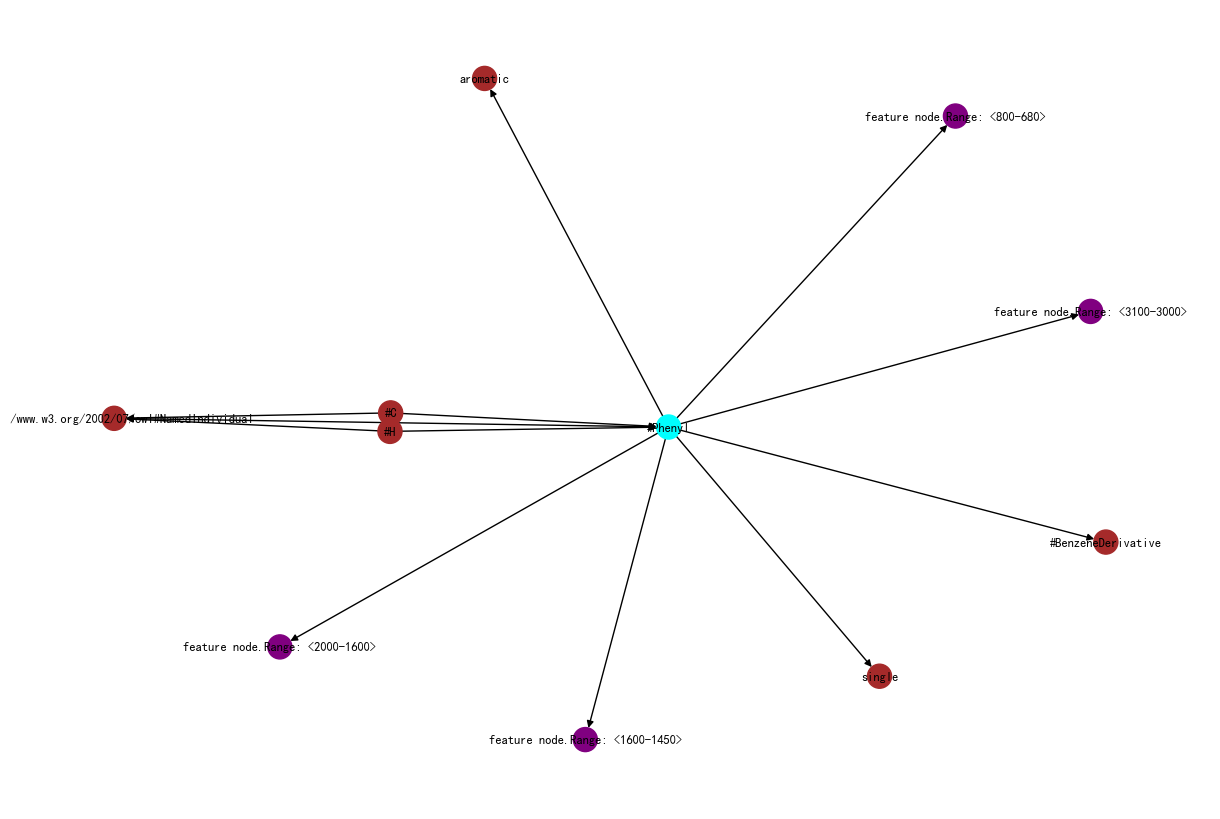

In [13]:
sub_graph = nx.generators.ego_graph(FG_graph, '#Phenyl', radius=1,undirected=True)
ppp = sub_graph

plt.rcParams['font.sans-serif'] = ['Simhei']  #显示中文
plt.rcParams['axes.unicode_minus'] = False    #显示负号
pos = nx.spring_layout(ppp)
#colors= [ppp.nodes[n]['color'] for n in ppp.nodes()]
colors = []
for n in ppp.nodes():
    try:colors.append(ppp.nodes[n]['color'])
    except:
        colors.append('brown')
        #print(n)

plt.figure(figsize=(12, 8))
nx.draw(ppp, pos=pos, with_labels=True,font_size=9,node_color=colors)
edge_labels = nx.get_edge_attributes(ppp, 'relatio')
nx.draw_networkx_edge_labels(ppp, pos=pos, edge_labels=edge_labels)
plt.show()

# Spec

In [14]:
# 加载光谱信息
Spectrum_loader = Spectrum_PygDataset()
SD = Spectrum_loader.data_loader('G:\Research\数据集\Pper4-Database\Spectral Database')
# SD里面有名字的相关储存

100%|██████████| 306/306 [00:02<00:00, 120.08it/s]


## Label

In [15]:
# 补充数据掩膜与标签
label = pd.read_excel(r'G:\Research\数据集\Pper4-Database\spect-分子式+学名_语义编码.xlsx')

Meta_Data = {}
for i in range(len(label)):
    meta_data = {}
    meta_data['label'] = label.iloc[i]['标签/双键结构，包括普通双键与芳香族']
    
    Meta_Data[label.iloc[i]['Molecular formula']] = meta_data
Meta_Data = utils.make_mask_proportion(Meta_Data)

In [16]:
spectrum_dataset = Spectrum_loader.preprocess(SD.data)
Spectrum_graph = Spectrum_loader.construct_graph(spectrum_dataset,kwargs=Meta_Data)

In [18]:
#Spectrum_loader.graph_visualisation(Spectrum_graph['(C6H4)2']['graph'])

# Save

In [25]:
# import pickle
# # 保存Spectrum_graph文件
# with open(f'../../Datasets/Data_for_different_task/{task_indicator}/Spectrum_graph.pkl', 'wb') as f:
#     pickle.dump(Spectrum_graph, f)
# # 保存FG_graph文件
# with open(f'../../Datasets/Data_for_different_task/{task_indicator}/FG_graph.pkl', 'wb') as f:
#     pickle.dump(FG_graph, f)

# Merge(used for pyg)

In [19]:
test_class = Merge_PygDataset(FG_graph,Spectrum_graph['(C6H4)2'], Name = '(C6H4)2')
connected_dictionary = test_class.preprocess()
all_Table,isexist,score_dict = test_class.Negative_relevant_information(is_print=False)
OP = test_class.construct_graph(connected_dictionary,all_Table,is_print=False)
fin = test_class.subgraph_extraction(hop=2)

In [27]:
#test_class.graph_visualisation(fin)